In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_csv('capstone2026.csv')

# ============================================================
# VARIABLE DEFINITIONS
# ============================================================

# Phase-based position variables
phase_pos = {
    'Pre-Hitch': ['BallXPreHitch', 'BallYPreHitch', 'BallZPreHitch'],
    'Hitch': ['BallXHitch', 'BallYHitch', 'BallZHitch'],
    'Post-Hitch': ['BallXPostHitch', 'BallYPostHitch', 'BallZPostHitch'],
    'Release': ['BallXRelease', 'BallYRelease', 'BallZRelease']
}

# Phase-based delta (movement) variables
phase_delta = {
    'Pre-Hitch': ['PreHitchXDelta', 'PreHitchYDelta', 'PreHitchZDelta'],
    'Hitch': ['HitchXDelta', 'HitchYDelta', 'HitchZDelta'],
    'Post-Hitch': ['PostHitchXDelta', 'PostHitchYDelta', 'PostHitchZDelta']
}

# Ball control variables
ball_control = [
    'MaxBallDist_PreHitch', 'MaxBallDist_Hitch', 'MaxBallDist_PostHitch',
    'Max.Ball.Cocked', 'Max.Ball.Released..Away.from.body.',
    'Delta.Ball.Cocked.vs.Release'
]

all_ball_vars = []
for v in phase_pos.values():
    all_ball_vars.extend(v)
for v in phase_delta.values():
    all_ball_vars.extend(v)
all_ball_vars.extend(ball_control)

outcome = 'Made'

# Ensure 'Made' column is string type for consistent palette mapping
df['Made'] = df['Made'].astype(str)

# Define a consistent palette for Made vs Missed
made_palette = {'True': '#2ecc71', 'False': '#e74c3c'}

# Convert Made to numeric for correlation
df['Made_num'] = df['Made'].map({'True': 1, 'False': 0})

# Extract segment info
shot_types = df['Shot.Type'].unique()
shot_locations = df['Shot.Location'].unique()

OVERALL CORRELATION WITH SHOT OUTCOME (Made)
PostHitchZDelta                      -0.089553
Max.Ball.Cocked                      -0.085544
HitchYDelta                           0.082587
Max.Ball.Released..Away.from.body.   -0.075087
MaxBallDist_PostHitch                -0.074185
BallZRelease                         -0.073095
PreHitchZDelta                        0.049204
BallYHitch                           -0.032592
BallYPreHitch                        -0.031650
BallYPostHitch                       -0.026091
BallYRelease                         -0.026008
PostHitchYDelta                       0.025705
MaxBallDist_PreHitch                 -0.024746
BallZPreHitch                        -0.018505
HitchZDelta                          -0.016069
PreHitchYDelta                       -0.009889
HitchXDelta                          -0.008434
BallZPostHitch                       -0.007914
BallZHitch                            0.005302
BallXHitch                            0.005022
BallXPreHitch  

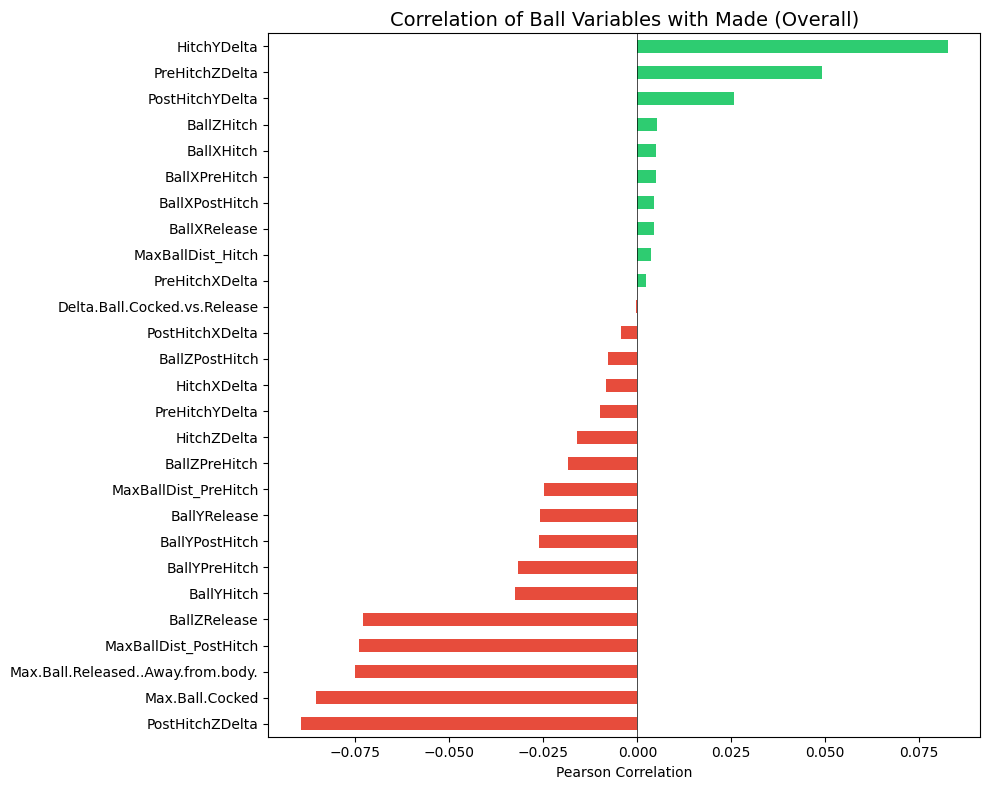

In [2]:
# ============================================================
# PART 1: OVERALL CORRELATION WITH MADE (BASELINE)
# ============================================================
print("=" * 60)
print("OVERALL CORRELATION WITH SHOT OUTCOME (Made)")
print("=" * 60)

corr_overall = df[all_ball_vars + ['Made_num']].corr()['Made_num'].drop('Made_num').sort_values(key=abs, ascending=False)
print(corr_overall)

# Horizontal bar chart of correlations
fig, ax = plt.subplots(figsize=(10, 8))
corr_overall.sort_values().plot(kind='barh', ax=ax, color=corr_overall.sort_values().apply(
    lambda x: '#2ecc71' if x > 0 else '#e74c3c'))
ax.set_title('Correlation of Ball Variables with Made (Overall)', fontsize=14)
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

CORRELATIONS BY SHOT TYPE

--- Off the Dribble (n=13614) ---
HitchYDelta                           0.143925
BallZRelease                         -0.089568
PostHitchZDelta                      -0.088504
Max.Ball.Cocked                      -0.084790
Max.Ball.Released..Away.from.body.   -0.079362
MaxBallDist_PostHitch                -0.074330
HitchZDelta                          -0.059059
BallYRelease                          0.052942
BallYPostHitch                        0.052464
BallYHitch                            0.042731
Name: Made_num, dtype: float64

--- Catch and Shoot (n=12254) ---
PostHitchZDelta                      -0.069145
Max.Ball.Cocked                      -0.064454
Max.Ball.Released..Away.from.body.   -0.064292
BallYHitch                           -0.062772
MaxBallDist_PostHitch                -0.061784
BallZRelease                         -0.061503
BallYPreHitch                        -0.061055
BallYRelease                         -0.059896
BallYPostHitch             

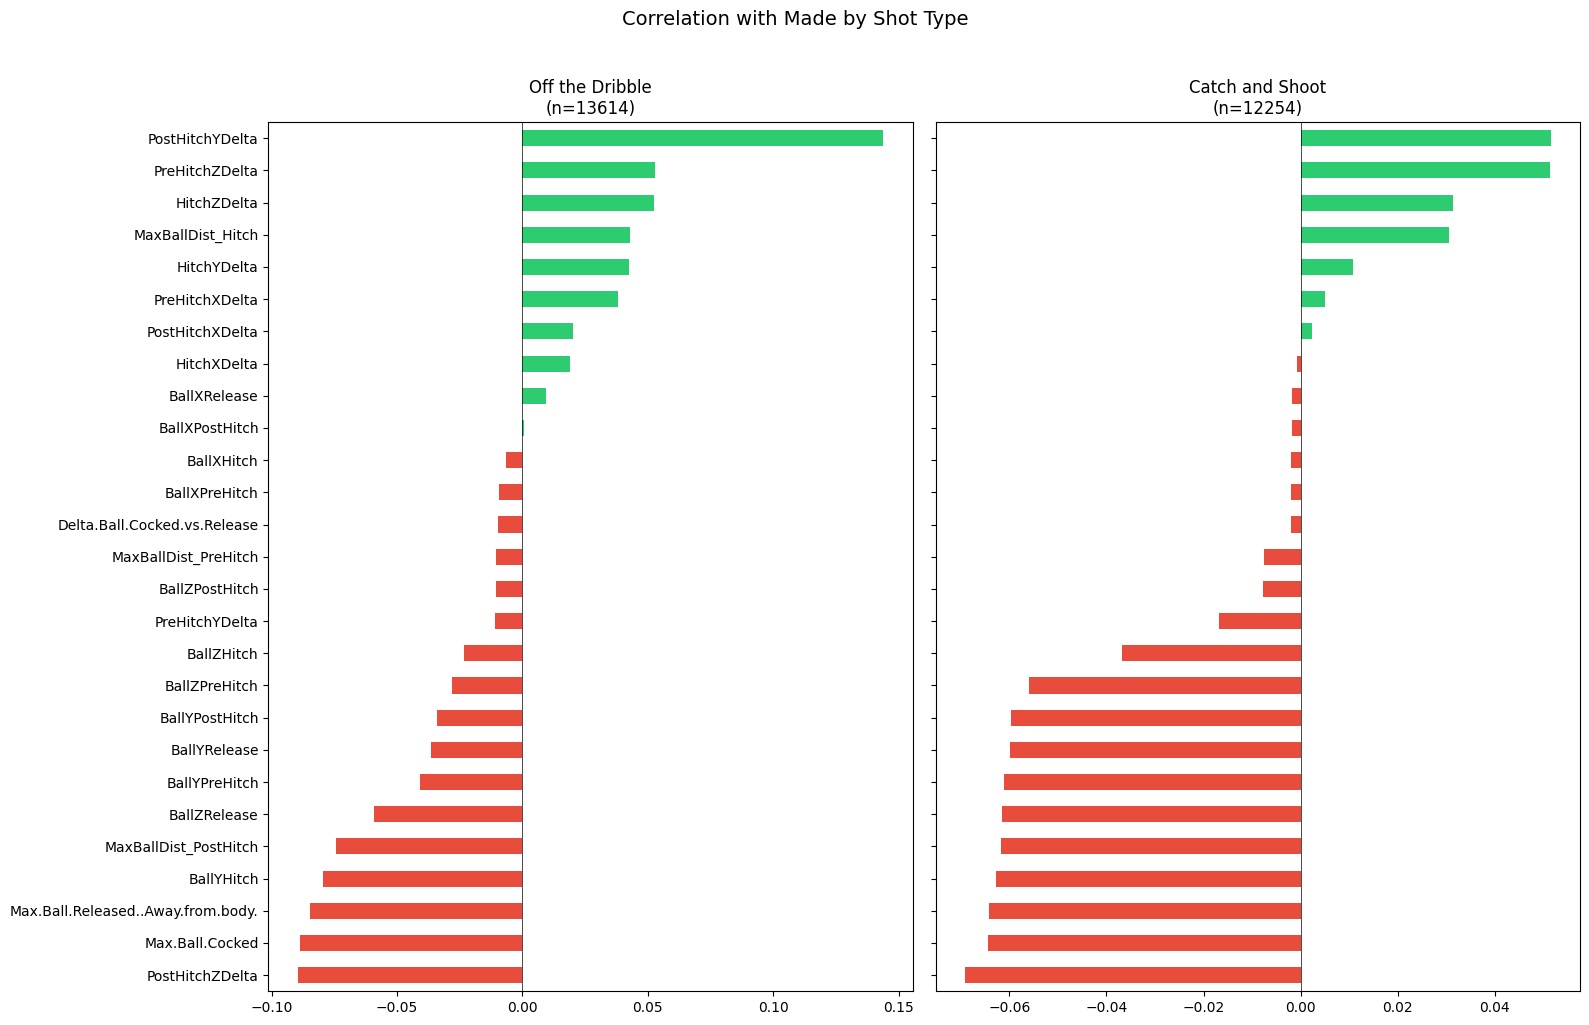

In [3]:
# ============================================================
# PART 2A: CORRELATIONS BY SHOT TYPE
# ============================================================
print("=" * 60)
print("CORRELATIONS BY SHOT TYPE")
print("=" * 60)

fig, axes = plt.subplots(1, len(shot_types), figsize=(8 * len(shot_types), 10), sharey=True)
if len(shot_types) == 1:
    axes = [axes]

for idx, st in enumerate(shot_types):
    subset = df[df['Shot.Type'] == st]
    corr = subset[all_ball_vars + ['Made_num']].corr()['Made_num'].drop('Made_num').sort_values(key=abs, ascending=False)
    print(f"\n--- {st} (n={len(subset)}) ---")
    print(corr.head(10))
    
    corr.sort_values().plot(kind='barh', ax=axes[idx], color=corr.sort_values().apply(
        lambda x: '#2ecc71' if x > 0 else '#e74c3c'))
    axes[idx].set_title(f'{st}\n(n={len(subset)})', fontsize=12)
    axes[idx].axvline(x=0, color='black', linewidth=0.5)

plt.suptitle('Correlation with Made by Shot Type', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

CORRELATIONS BY SHOT LOCATION

--- Left Corner Three (n=4990) ---
Delta.Ball.Cocked.vs.Release         -0.041060
Max.Ball.Released..Away.from.body.   -0.036855
PreHitchZDelta                       -0.034185
MaxBallDist_PreHitch                 -0.032538
HitchYDelta                           0.029481
MaxBallDist_PostHitch                 0.027560
BallZRelease                         -0.024265
BallZHitch                           -0.024014
PostHitchXDelta                      -0.023069
BallZPostHitch                       -0.023026
Name: Made_num, dtype: float64

--- Right Corner Three (n=4958) ---
BallZHitch                     -0.080970
BallZRelease                   -0.076184
BallZPreHitch                  -0.072489
BallZPostHitch                 -0.059518
Delta.Ball.Cocked.vs.Release   -0.046838
BallXPreHitch                  -0.042947
MaxBallDist_PreHitch           -0.036998
BallXHitch                     -0.035252
BallXPostHitch                 -0.033467
BallXRelease               

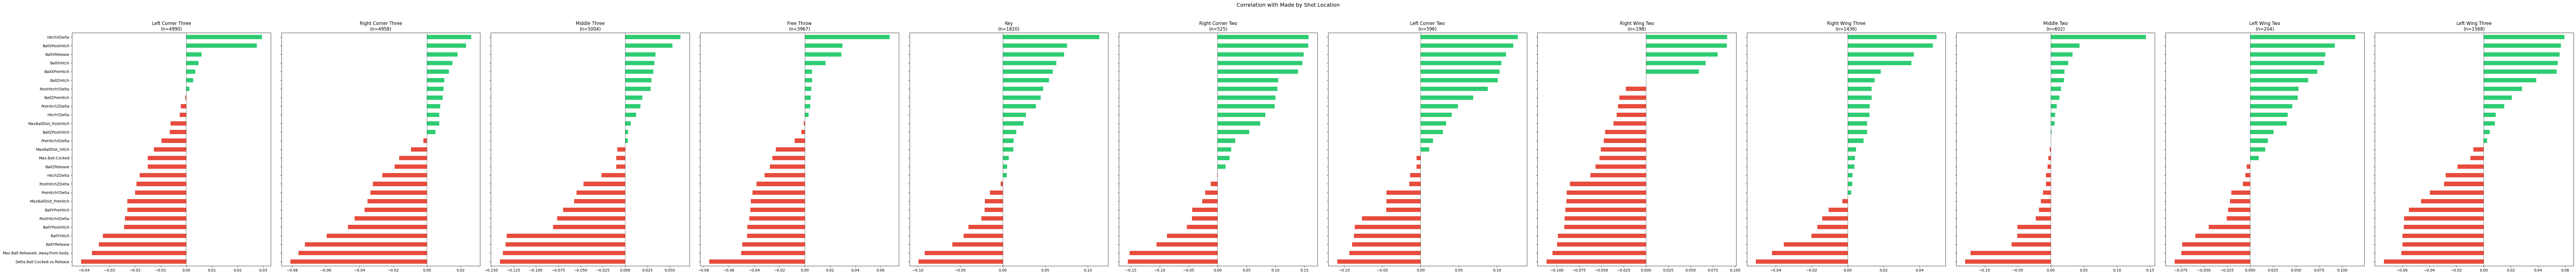

In [4]:
# ============================================================
# PART 2B: CORRELATIONS BY SHOT LOCATION
# ============================================================
print("=" * 60)
print("CORRELATIONS BY SHOT LOCATION")
print("=" * 60)

fig, axes = plt.subplots(1, len(shot_locations), figsize=(8 * len(shot_locations), 10), sharey=True)
if len(shot_locations) == 1:
    axes = [axes]

for idx, sl in enumerate(shot_locations):
    subset = df[df['Shot.Location'] == sl]
    corr = subset[all_ball_vars + ['Made_num']].corr()['Made_num'].drop('Made_num').sort_values(key=abs, ascending=False)
    print(f"\n--- {sl} (n={len(subset)}) ---")
    print(corr.head(10))
    
    corr.sort_values().plot(kind='barh', ax=axes[idx], color=corr.sort_values().apply(
        lambda x: '#2ecc71' if x > 0 else '#e74c3c'))
    axes[idx].set_title(f'{sl}\n(n={len(subset)})', fontsize=12)
    axes[idx].axvline(x=0, color='black', linewidth=0.5)

plt.suptitle('Correlation with Made by Shot Location', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

PHASE-BY-PHASE: MADE vs MISSED — Ball Position


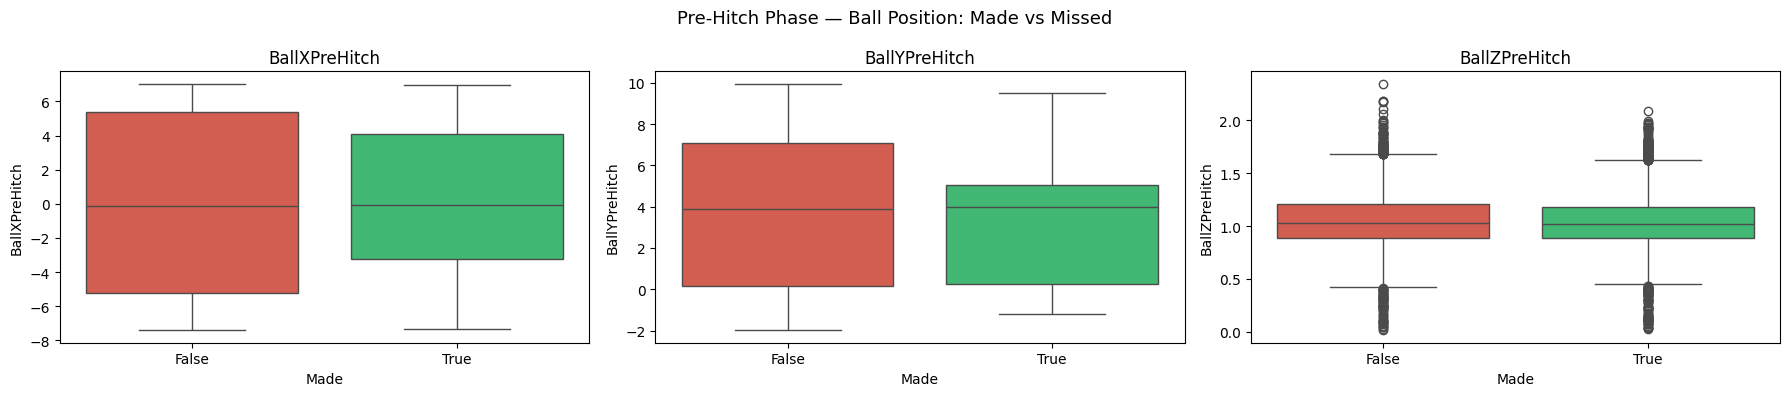

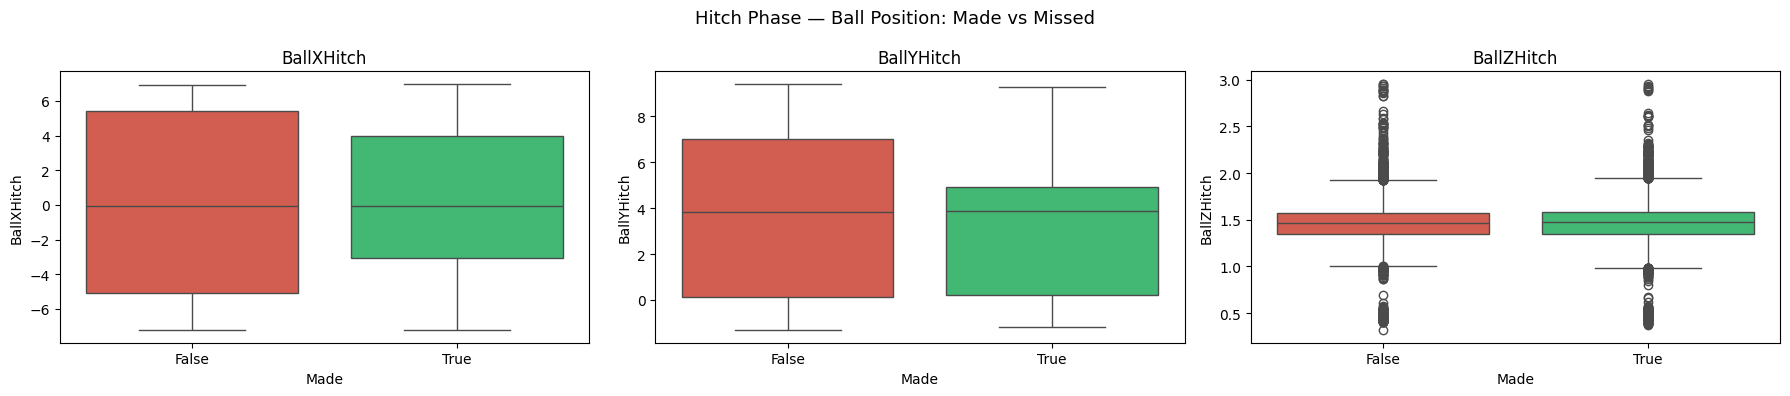

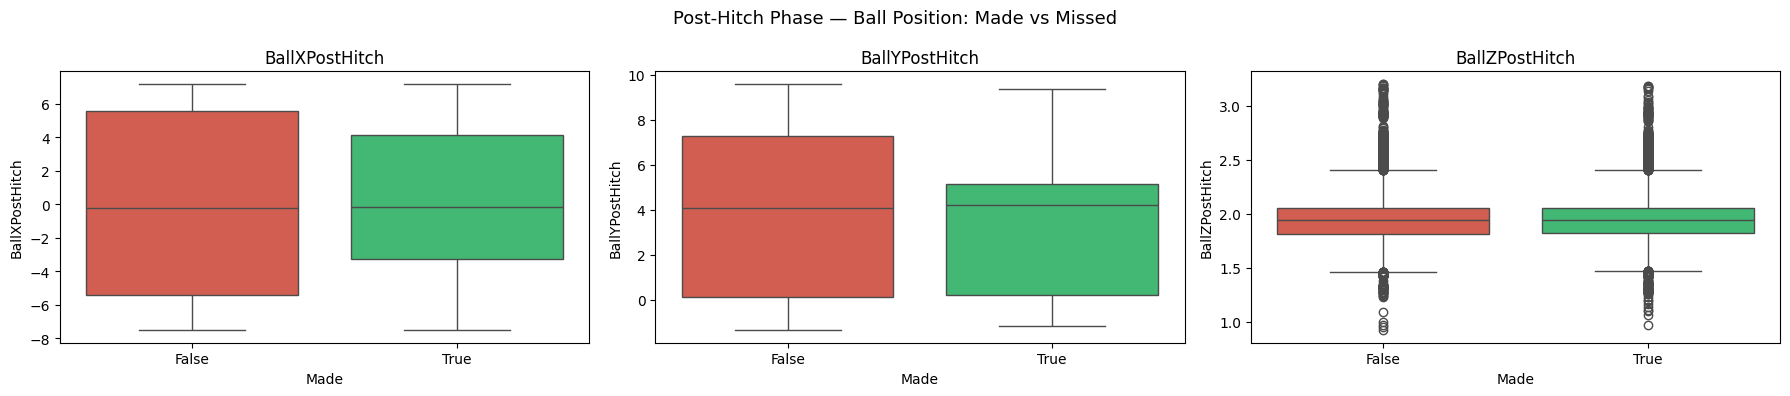

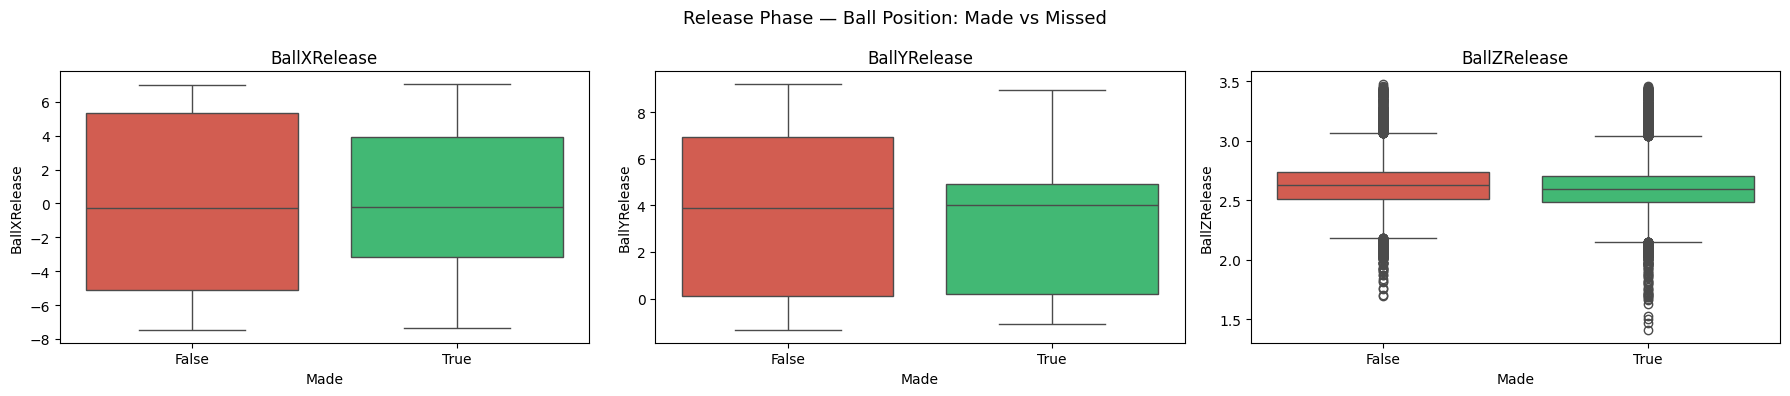

In [5]:
# ============================================================
# PART 3A: PHASE-BY-PHASE — BALL POSITION (Made vs Missed)
# ============================================================
print("=" * 60)
print("PHASE-BY-PHASE: MADE vs MISSED — Ball Position")
print("=" * 60)

for phase_name, vars_list in phase_pos.items():
    fig, axes = plt.subplots(1, len(vars_list), figsize=(6 * len(vars_list), 4))
    for i, var in enumerate(vars_list):
        sns.boxplot(data=df, x='Made', y=var, hue='Made', ax=axes[i], palette=made_palette, legend=False)
        axes[i].set_title(f'{var}')
    plt.suptitle(f'{phase_name} Phase — Ball Position: Made vs Missed', fontsize=13)
    plt.tight_layout()
    plt.show()

PHASE-BY-PHASE: MADE vs MISSED — Ball Movement (Delta)


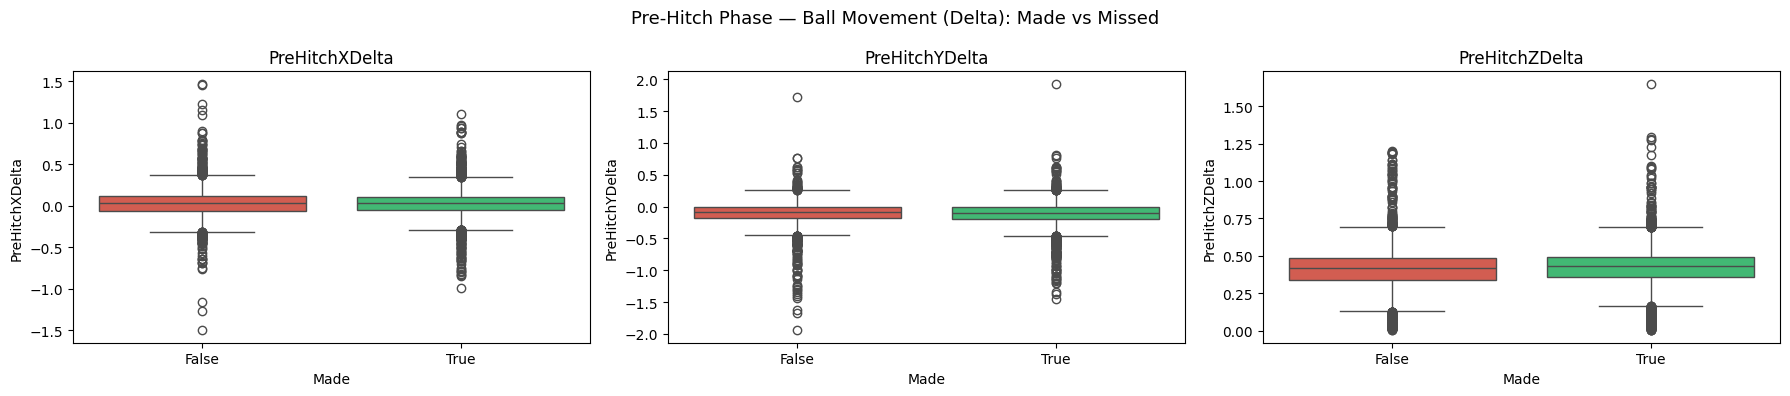

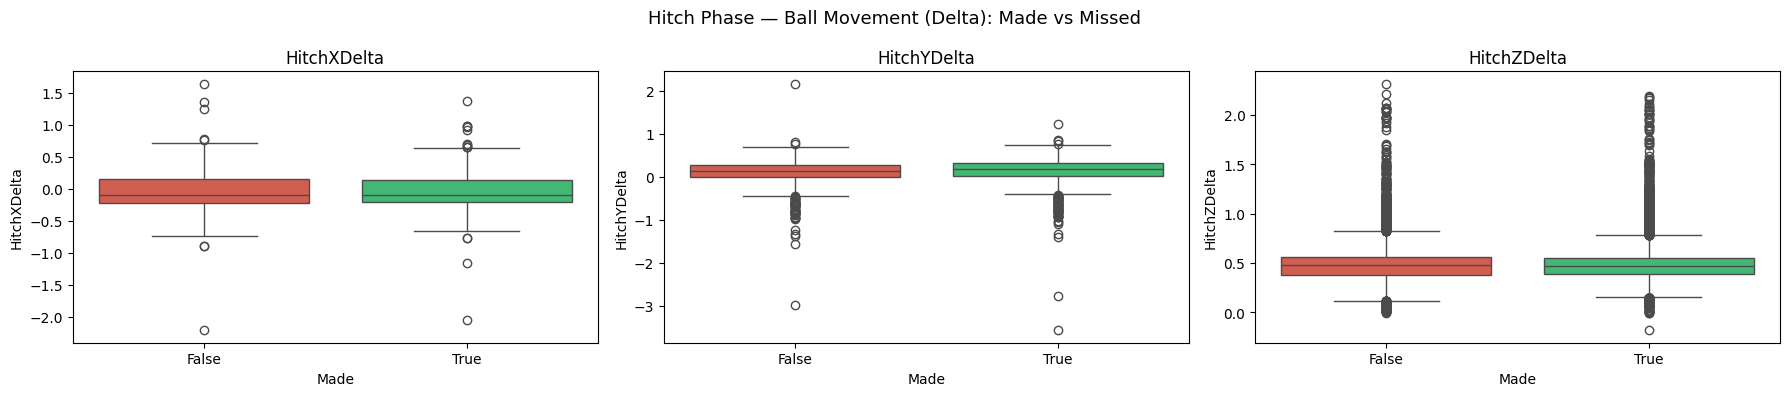

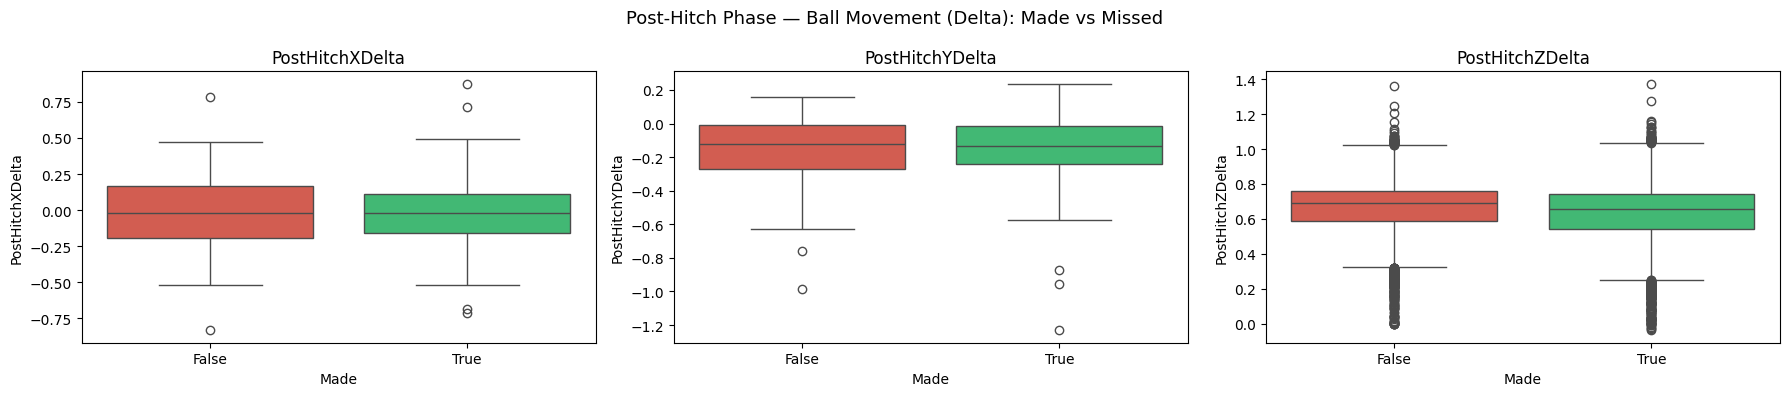

In [6]:
# ============================================================
# PART 3B: PHASE-BY-PHASE — BALL MOVEMENT DELTAS (Made vs Missed)
# ============================================================
print("=" * 60)
print("PHASE-BY-PHASE: MADE vs MISSED — Ball Movement (Delta)")
print("=" * 60)

for phase_name, vars_list in phase_delta.items():
    fig, axes = plt.subplots(1, len(vars_list), figsize=(6 * len(vars_list), 4))
    for i, var in enumerate(vars_list):
        sns.boxplot(data=df, x='Made', y=var, hue='Made', ax=axes[i], palette=made_palette, legend=False)
        axes[i].set_title(f'{var}')
    plt.suptitle(f'{phase_name} Phase — Ball Movement (Delta): Made vs Missed', fontsize=13)
    plt.tight_layout()
    plt.show()

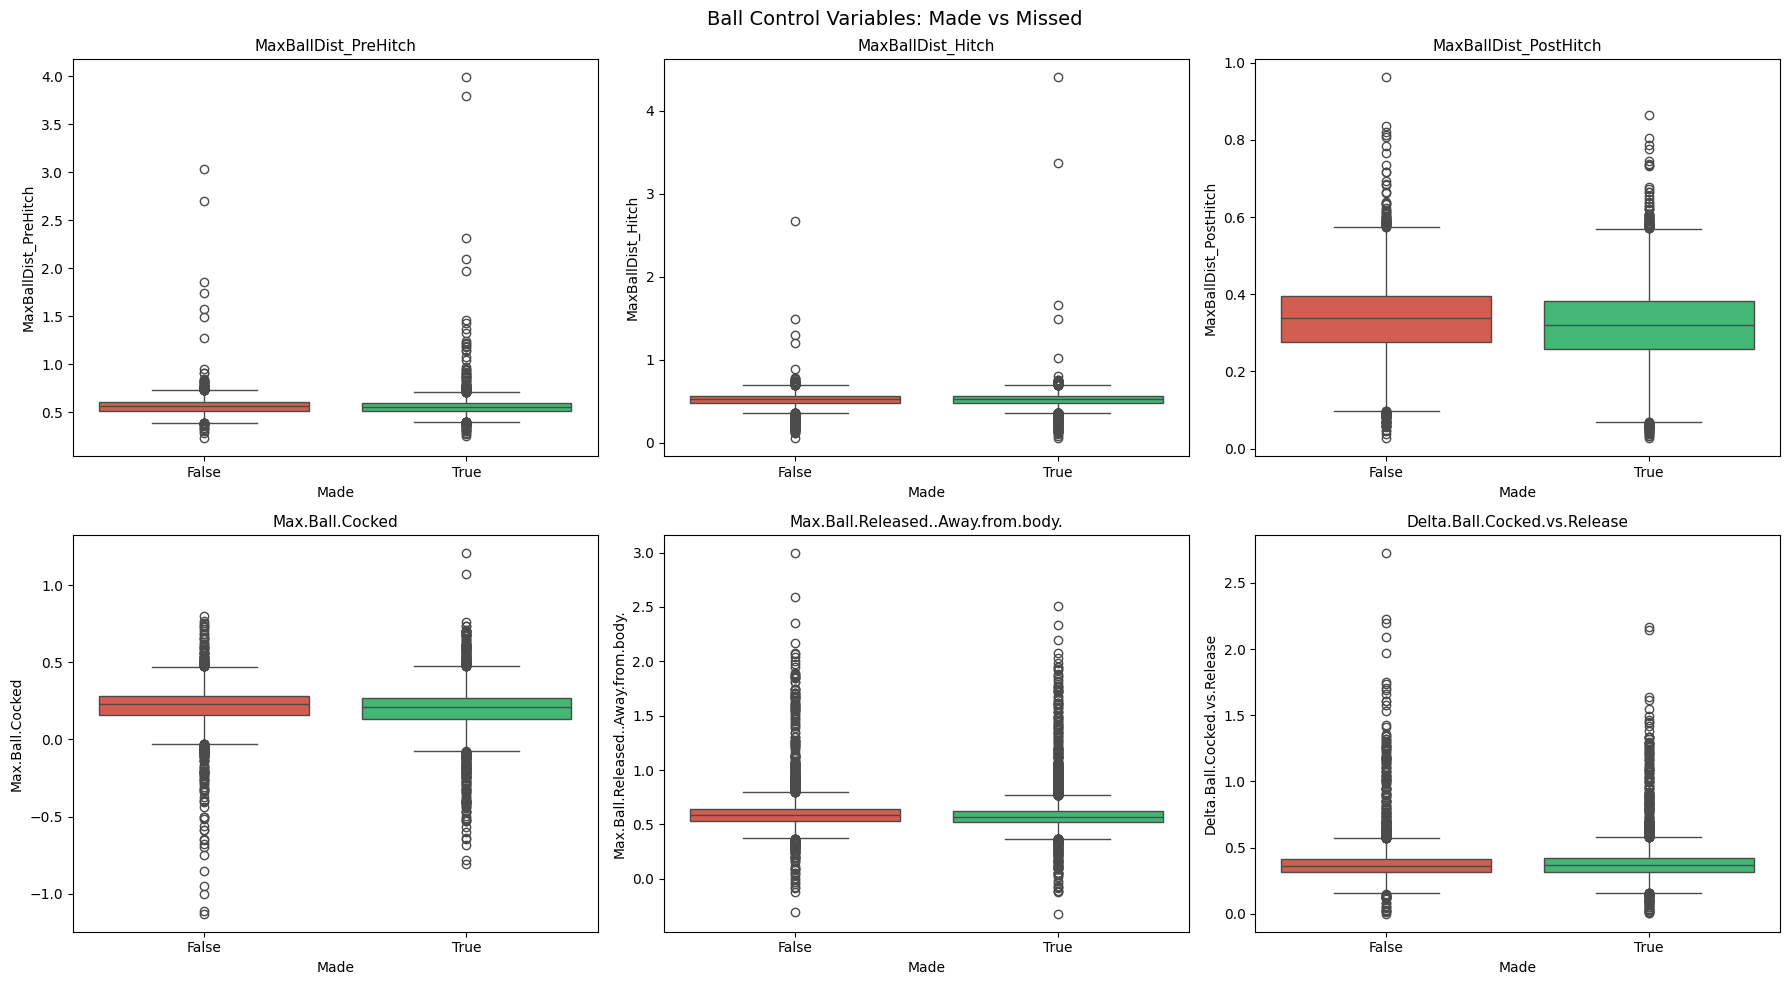

In [9]:
# ============================================================
# PART 3C: BALL CONTROL VARIABLES (Made vs Missed)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, var in enumerate(ball_control):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=df, x='Made', y=var, hue='Made', ax=ax, palette=made_palette, legend=False)
    ax.set_title(var, fontsize=11)
plt.suptitle('Ball Control Variables: Made vs Missed', fontsize=14)
plt.tight_layout()
plt.show()

PHASE-BY-PHASE SEGMENTED BY SHOT TYPE

Shot Type: Off the Dribble (n=13614)


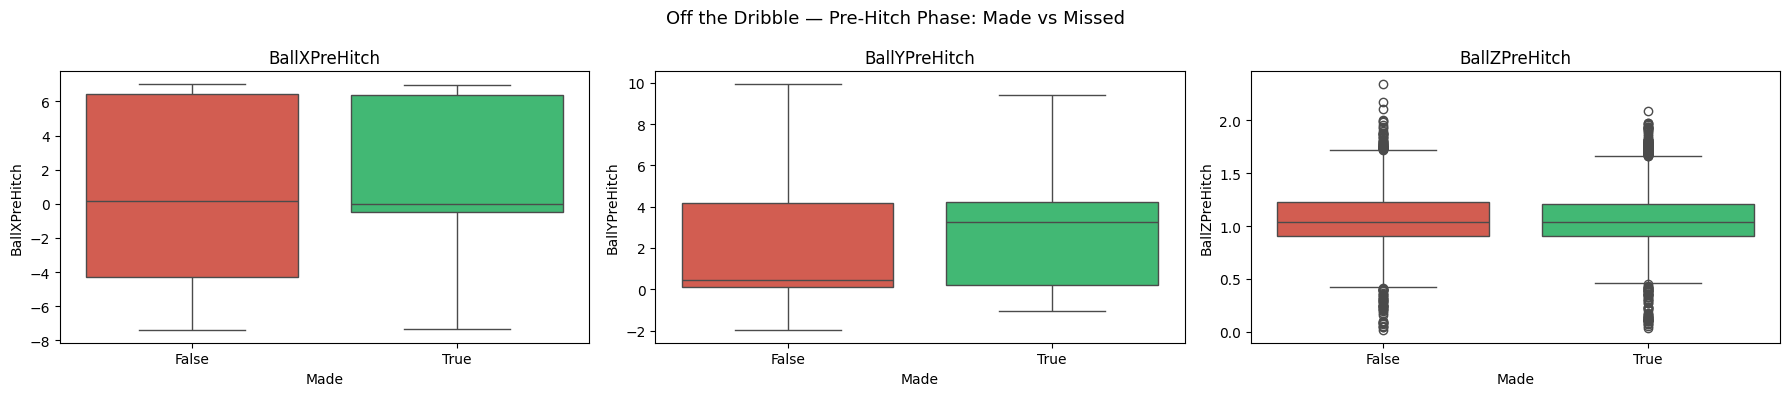

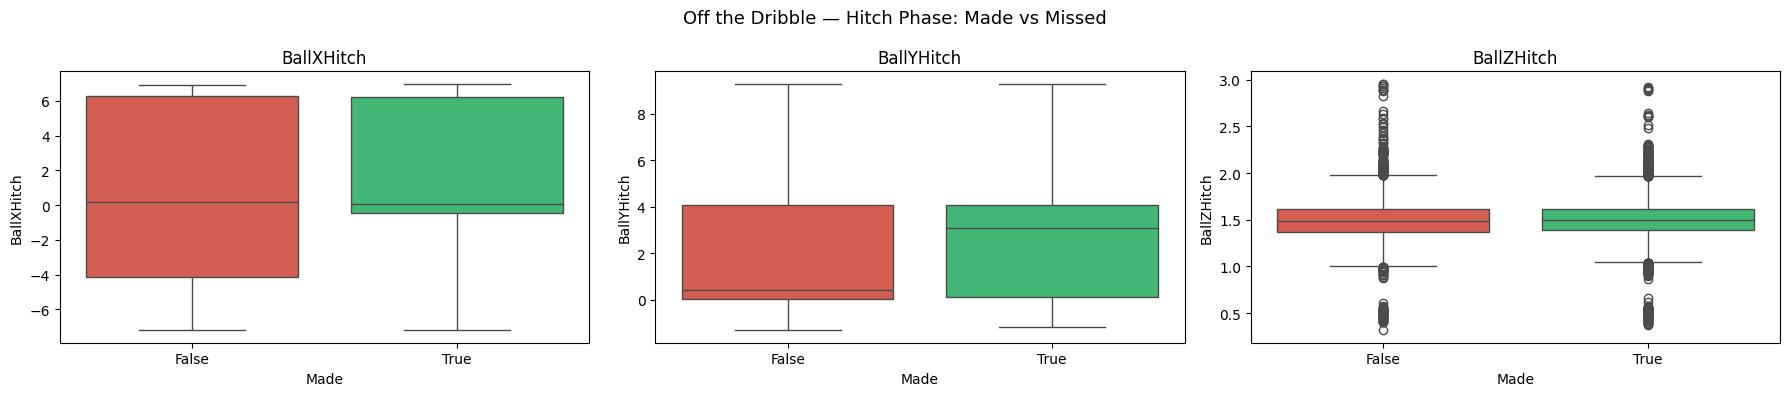

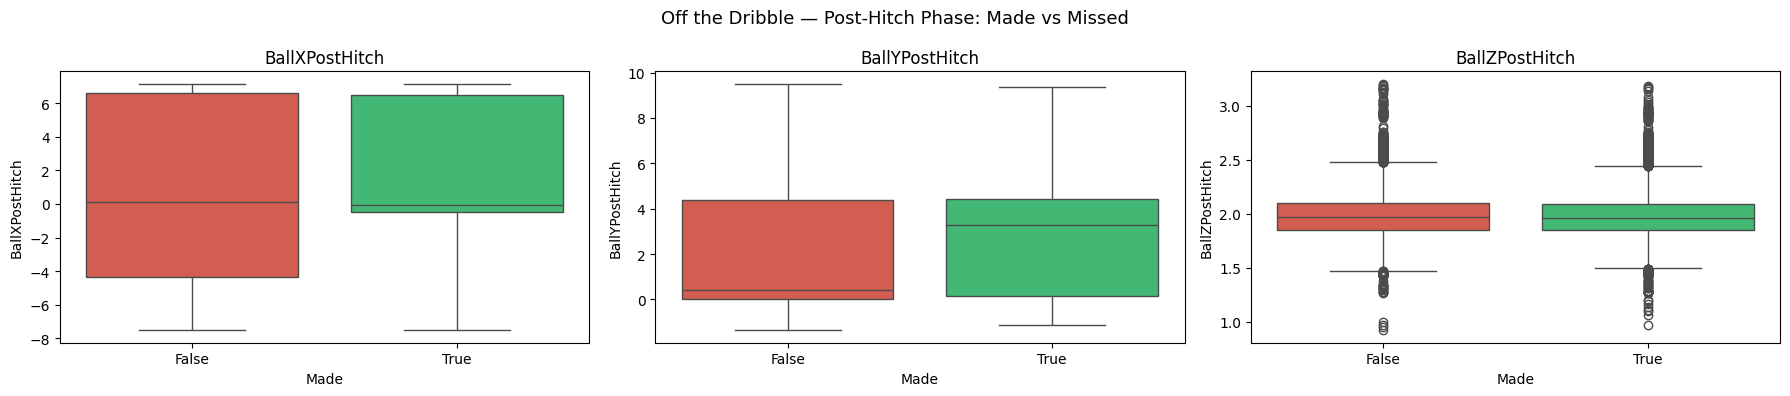

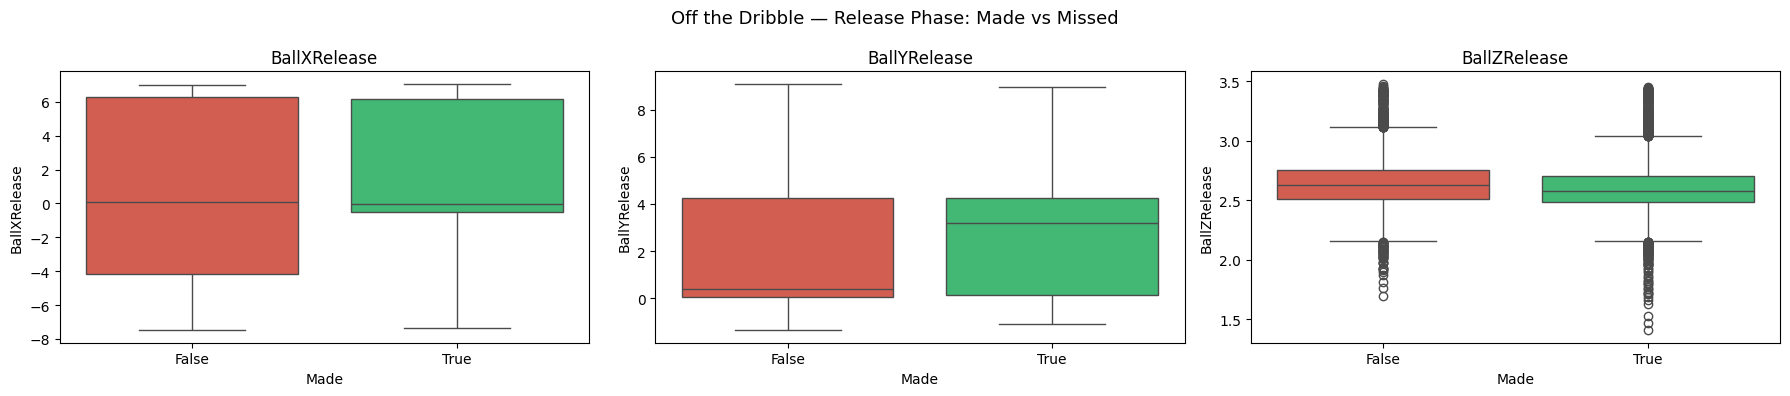


Shot Type: Catch and Shoot (n=12254)


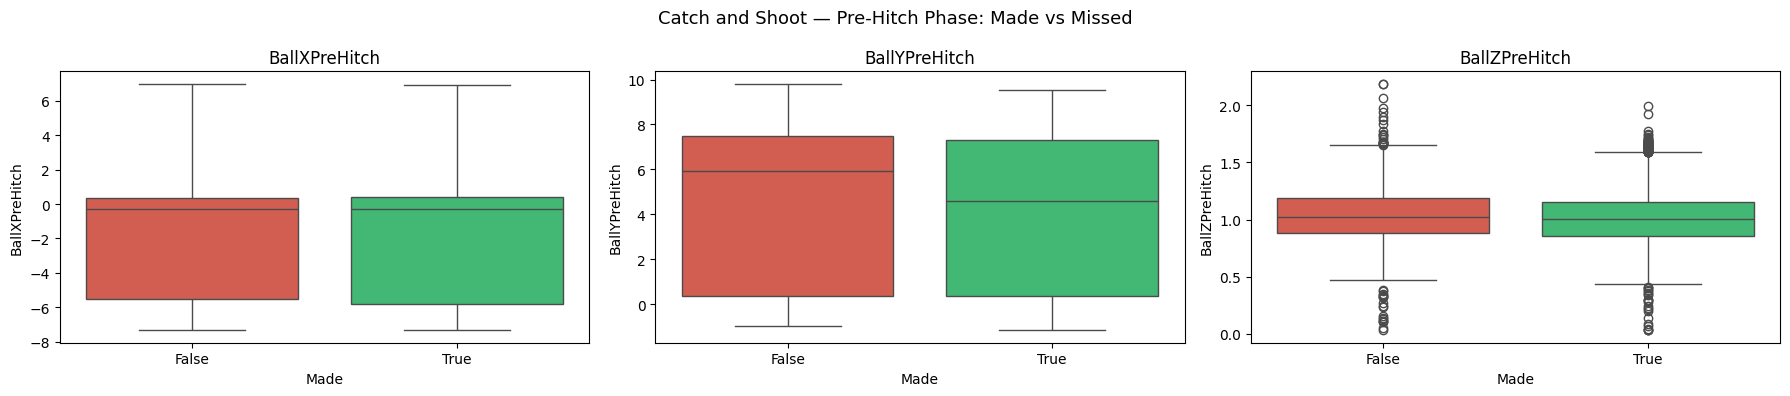

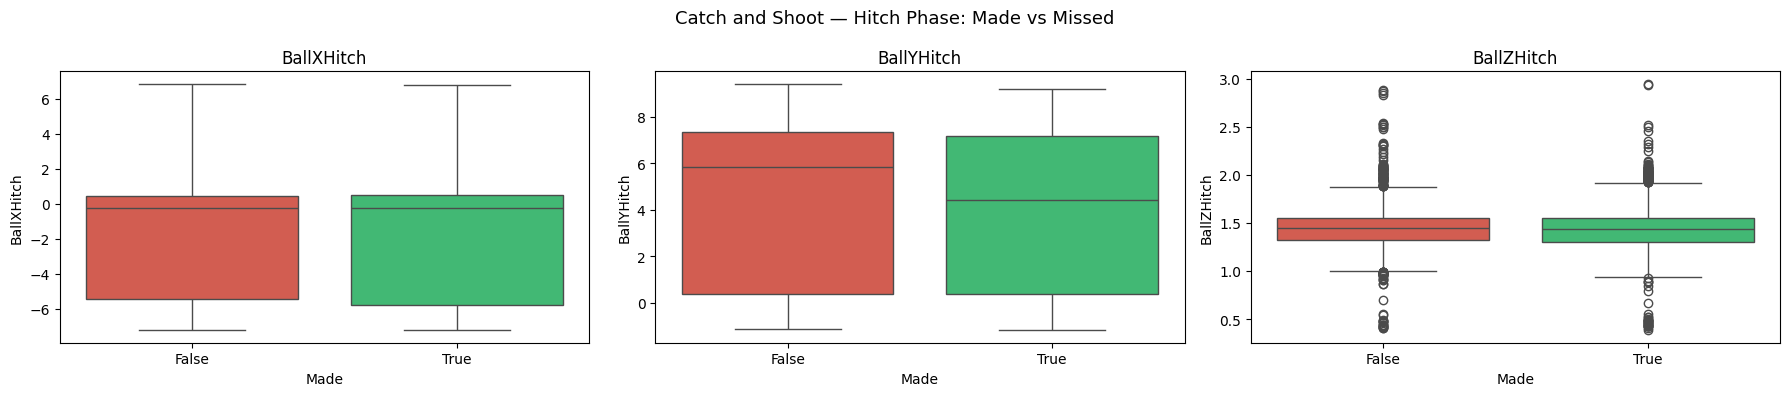

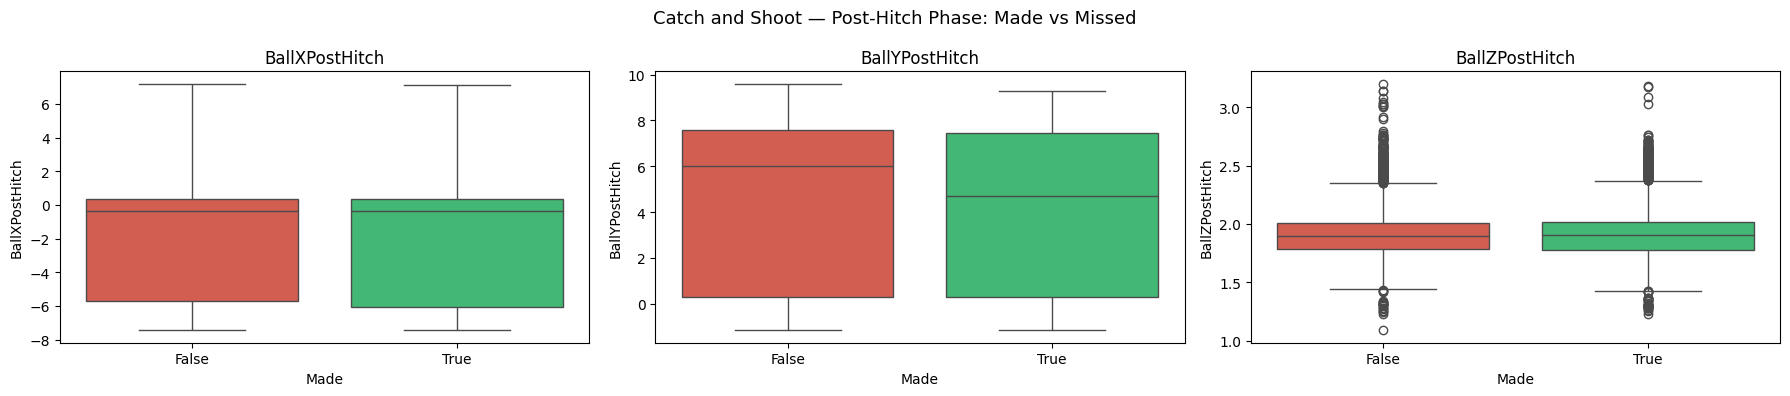

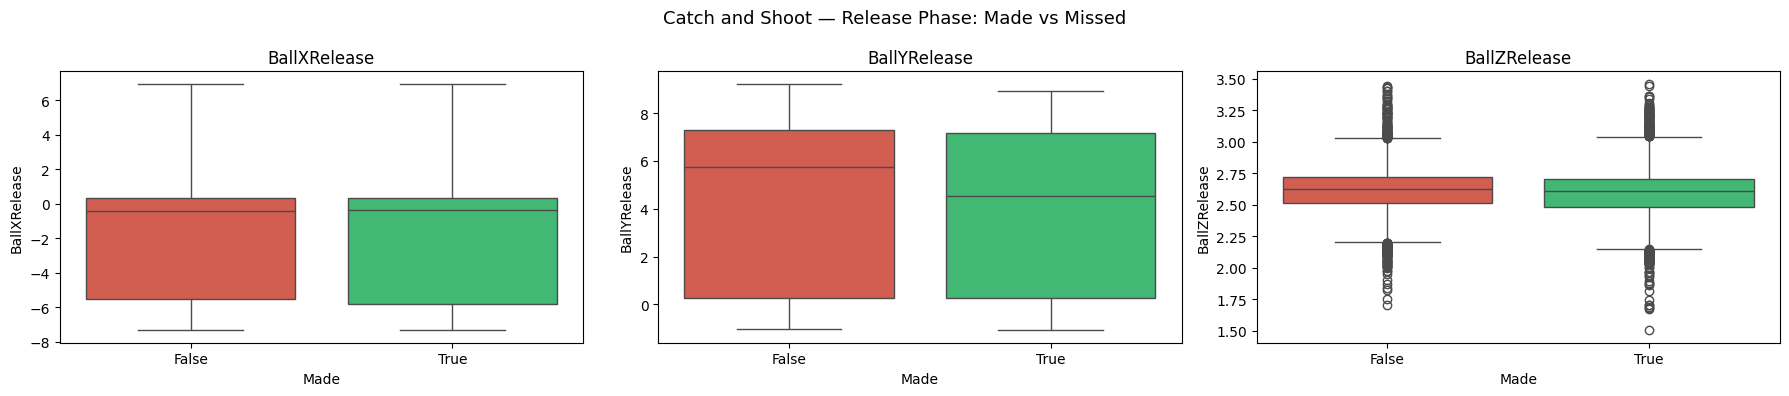

In [8]:
# ============================================================
# PART 4: PHASE-BY-PHASE SEGMENTED BY SHOT TYPE
# ============================================================
print("=" * 60)
print("PHASE-BY-PHASE SEGMENTED BY SHOT TYPE")
print("=" * 60)

for st in shot_types:
    subset = df[df['Shot.Type'] == st]
    print(f"\n{'='*40}")
    print(f"Shot Type: {st} (n={len(subset)})")
    print(f"{'='*40}")
    
    for phase_name, vars_list in phase_pos.items():
        fig, axes = plt.subplots(1, len(vars_list), figsize=(6 * len(vars_list), 4))
        for i, var in enumerate(vars_list):
            sns.boxplot(data=subset, x='Made', y=var, hue='Made', ax=axes[i],
                       palette=made_palette, legend=False)
            axes[i].set_title(f'{var}')
        plt.suptitle(f'{st} — {phase_name} Phase: Made vs Missed', fontsize=13)
        plt.tight_layout()
        plt.show()

INTER-VARIABLE CORRELATION HEATMAP


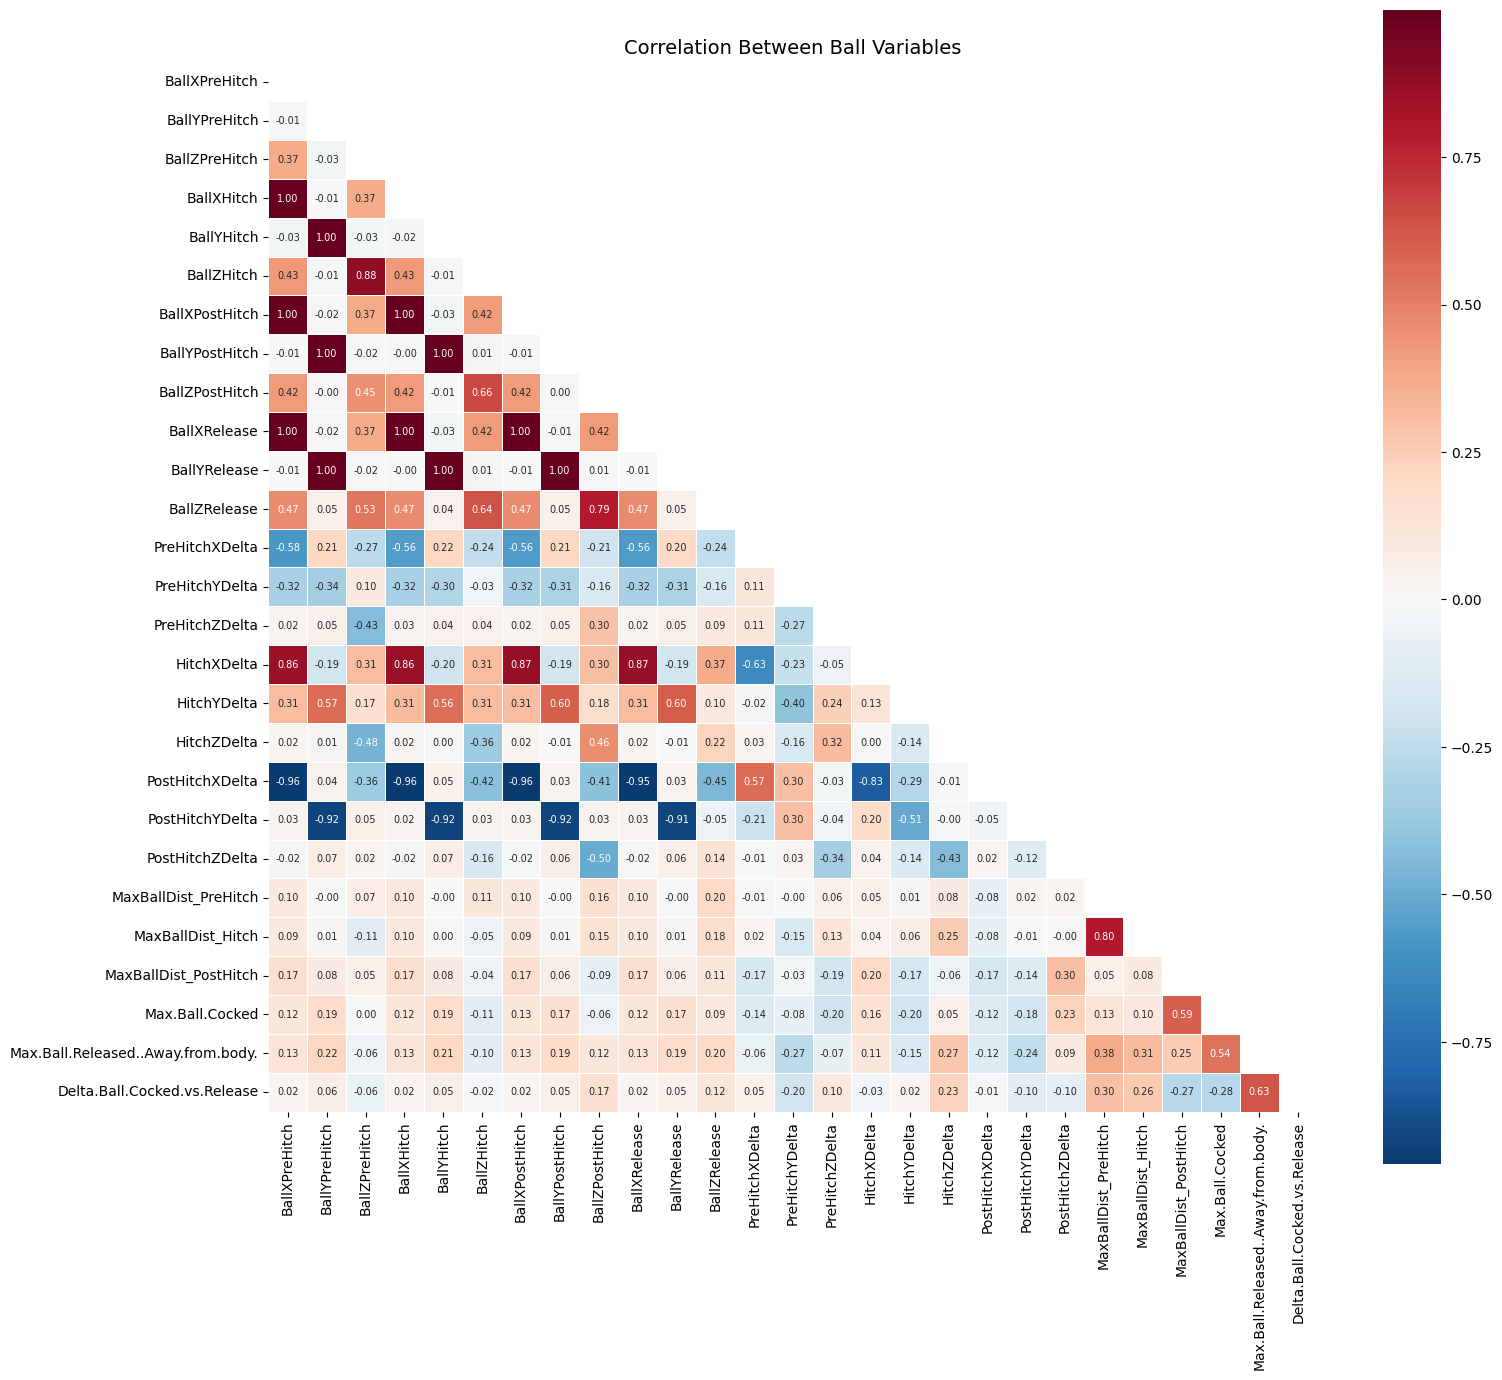

In [10]:
# ============================================================
# PART 5: CORRELATION HEATMAP ACROSS ALL BALL VARIABLES
# ============================================================
print("=" * 60)
print("INTER-VARIABLE CORRELATION HEATMAP")
print("=" * 60)

corr_matrix = df[all_ball_vars].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Between Ball Variables', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PART 6: EFFECT SIZE (COHEN'S D) FOR MADE vs MISSED
# ============================================================
print("=" * 60)
print("EFFECT SIZE (COHEN'S D) — MADE vs MISSED")
print("=" * 60)

def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std if pooled_std > 0 else 0

made = df[df['Made'] == 'True']
missed = df[df['Made'] == 'False']

effect_sizes = {}
for var in all_ball_vars:
    d = cohens_d(made[var].dropna(), missed[var].dropna())
    effect_sizes[var] = d

effect_df = pd.Series(effect_sizes).sort_values(key=abs, ascending=False)
print(effect_df)

fig, ax = plt.subplots(figsize=(10, 8))
effect_df.sort_values().plot(kind='barh', ax=ax,
    color=effect_df.sort_values().apply(lambda x: '#2ecc71' if x > 0 else '#e74c3c'))
ax.set_title("Cohen's d Effect Size: Made vs Missed", fontsize=14)
ax.set_xlabel("Cohen's d")
ax.axvline(x=0, color='black', linewidth=0.5)
ax.axvline(x=0.2, color='gray', linewidth=0.5, linestyle='--', label='Small effect')
ax.axvline(x=-0.2, color='gray', linewidth=0.5, linestyle='--')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PART 7: SUMMARY TABLE — TOP VARIABLES BY SEGMENT
# ============================================================
print("=" * 60)
print("SUMMARY: TOP 5 MOST IMPACTFUL VARIABLES PER SEGMENT")
print("=" * 60)

segments = [('Overall', df)]
for st in shot_types:
    segments.append((f'Shot Type: {st}', df[df['Shot.Type'] == st]))
for sl in shot_locations:
    segments.append((f'Location: {sl}', df[df['Shot.Location'] == sl]))

summary_rows = []
for seg_name, seg_df in segments:
    corr = seg_df[all_ball_vars + ['Made_num']].corr()['Made_num'].drop('Made_num')
    top5 = corr.abs().sort_values(ascending=False).head(5)
    for var_name in top5.index:
        summary_rows.append({
            'Segment': seg_name,
            'Variable': var_name,
            'Correlation': corr[var_name],
            'Abs_Correlation': abs(corr[var_name]),
            'n': len(seg_df)
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# In-Depth Interpretation of Summary Results

## Overview

The summary table above identifies the **top 5 most correlated ball-handling variables with shot outcome (Made)** across every segment — overall, by shot type, and by shot location. All correlations are relatively small in magnitude (|r| < 0.16), which is expected in a complex motor task like shooting a basketball where many factors contribute to the outcome. However, because the dataset is large (n = 25,868 total shots), even small correlations can be statistically meaningful and practically informative for coaching decisions.

---

## Overall (n = 25,868)

| Variable | r | Interpretation |
|---|---|---|
| **PostHitchZDelta** | -0.090 | The most impactful variable overall. A *negative* correlation means that **greater upward (Z-axis) ball movement during the post-hitch phase is associated with more misses**. This suggests that excessive vertical ball displacement after the hitch disrupts shot accuracy — shooters who keep their post-hitch lift more controlled tend to make more shots. |
| **Max.Ball.Cocked** | -0.086 | How far back (cocked) the ball goes before release. **More extreme cocking is associated with misses.** Over-cocking the ball may introduce variability in arc and trajectory, making it harder to achieve a consistent release. |
| **HitchYDelta** | +0.083 | The only *positive* correlation in the overall top 5. **Greater forward (Y-axis) movement during the hitch phase is associated with makes.** This could reflect a smoother forward transfer of momentum into the shot, rather than an abrupt or stalled hitch motion. |
| **Max.Ball.Released (Away from body)** | -0.075 | **Shots where the ball is released farther away from the body are more likely to miss.** This implies that keeping the ball closer to the body at release — maintaining a compact release point — is beneficial for accuracy. |
| **MaxBallDist_PostHitch** | -0.074 | The maximum distance the ball reaches from the body during the post-hitch phase. **Greater distance = more misses.** Consistent with the theme that controlled, compact ball handling through the shooting motion leads to better outcomes. |

**Key Takeaway (Overall):** The dominant pattern is that **greater ball movement, extension, and displacement throughout the shooting motion — particularly in the vertical (Z) and away-from-body dimensions — is associated with missed shots.** Shooters who maintain a more compact, controlled ball path tend to be more accurate.

---

## By Shot Type

### Off the Dribble (n = 13,614)
- **HitchYDelta (+0.144)** is the strongest predictor — even more so than in the overall data. Off-the-dribble shots likely benefit from a smooth, forward-momentum hitch because the player is already in motion. A strong forward hitch transfer helps maintain rhythm.
- **BallZRelease (-0.090)** appears here but not in catch-and-shoot. The vertical position of the ball at release matters more for dribble shots, possibly because the ball is gathered from a lower position and release height variability is greater.
- The remaining variables (PostHitchZDelta, Max.Ball.Cocked, Max.Ball.Released) mirror the overall findings, reinforcing that ball control through the shot motion is critical even when coming off the dribble.

### Catch and Shoot (n = 12,254)
- **PostHitchZDelta (-0.069)** and **Max.Ball.Cocked (-0.064)** remain the top predictors, but the correlations are noticeably *weaker* than off-the-dribble. This may be because catch-and-shoot situations are more structured and less variable.
- **BallYHitch (-0.063)** appears uniquely here. A *negative* correlation with the Y-position at hitch suggests that ball position being too far forward during the hitch hurts accuracy — perhaps indicating the catch position is too far out front.
- **MaxBallDist_PostHitch (-0.062)** again confirms the compactness theme.

**Key Takeaway (Shot Type):** Off-the-dribble shots are more sensitive to ball-handling mechanics, and the forward momentum (HitchYDelta) is especially important. Catch-and-shoot shots show smaller effects overall, which could reflect the simpler gathering motion involved.

---

## By Shot Location

### Corner Threes (Left n=4,990 / Right n=4,958)
- **Left Corner:** `Delta.Ball.Cocked.vs.Release` (-0.041) is the top variable — the difference between the cocked and release ball positions. A larger delta (more re-positioning) is associated with misses. Correlations are notably **weak** across the board, suggesting corner threes are less influenced by ball position variables, possibly because the shot is more set and the geometry is simpler (closer to the basket, no backboard angle adjustment needed).
- **Right Corner:** `BallZHitch` (-0.081) and other Z-position variables dominate. **Ball height at various phases is more predictive from the right corner.** This could indicate that release point consistency in the vertical plane is particularly important from this angle.

### Middle Three (n = 5,004)
- **BallYHitch (-0.140)** is the strongest correlation of any location segment. This is a standout finding: **the forward/backward (Y) position of the ball at the hitch point is highly predictive for middle threes.** A ball positioned too far forward (more negative Y) during the hitch is associated with misses. From center court, there's no lateral correction margin — the shot must go straight, so Y-plane consistency is critical.
- All top 4 variables are BallY positions at various phases, confirming that **Y-axis consistency throughout the shot is the dominant factor for center three-point shots.**
- **BallZHitch (-0.080)** is the only non-Y variable in the top 5, adding a height component.

### Free Throw (n = 3,967)
- **BallZRelease (-0.076)** leads — higher release point is slightly associated with misses, or more likely, *variability* in release height hurts accuracy.
- **PostHitchXDelta (+0.067)** is uniquely positive here — lateral ball movement in the post-hitch phase is beneficial. This is unusual and could reflect the free throw's stationary nature: some lateral adjustment during the gather might actually help alignment.
- BallY variables at hitch, post-hitch, and release appear again, with modest negative correlations.

### Key (n = 1,820)
- **HitchYDelta (+0.113)** is the strongest variable. From the key area (mid-range around the paint), the forward momentum of the hitch is especially predictive — similar to off-the-dribble shots, since many key-area shots are likely pull-ups or floaters.
- **Max.Ball.Released (-0.099)** and **Delta.Ball.Cocked.vs.Release (-0.092)** show that compact ball handling is critical in this contested zone.

### Corner Twos (Right n=525 / Left n=596)
- These are the **smallest sample sizes** but show the **largest correlations** in the dataset.
- **Right Corner Two:** BallX positions dominate (r ≈ 0.15-0.16), meaning lateral ball positioning is critical. `MaxBallDist_PostHitch` and `PostHitchXDelta` are negatively correlated — excessive lateral ball movement during post-hitch hurts accuracy.
- **Left Corner Two:** BallY positions dominate with positive correlations (r ≈ 0.11-0.13), meaning more forward ball positioning at various phases helps. `PreHitchXDelta` (-0.109) is a notable negative — lateral movement before the hitch hurts.
- **Caution:** With n < 600, these correlations are less stable and may not generalize.

### Wing Locations
- **Right/Left Wing Two (n ≈ 200):** Very small samples. Various position and delta variables emerge, but results should be interpreted cautiously.
- **Right/Left Wing Three (n ≈ 1,400-1,568):** `Delta.Ball.Cocked.vs.Release` appears at the top for both wings — the difference between the ball's cocked and released positions matters. Keeping this delta small (compact shot) is associated with makes.

---

## Key Themes Across All Segments

1. **Compactness wins:** Variables measuring ball distance from the body (`Max.Ball.Cocked`, `Max.Ball.Released`, `MaxBallDist_PostHitch`) consistently show negative correlations with making shots. Keeping the ball close throughout the shooting motion is beneficial.

2. **Vertical displacement hurts:** `PostHitchZDelta` (vertical ball movement after the hitch) is a recurring negative predictor across multiple segments. Excessive vertical ball travel introduces variability.

3. **Forward momentum helps:** `HitchYDelta` (forward ball movement during the hitch) is consistently *positively* correlated — a smooth forward transfer of momentum into the shot aids accuracy.

4. **Location determines which axis matters most:** Y-axis (forward/back) variables dominate for middle/center shots, Z-axis (height) variables dominate for corner threes, and X-axis (lateral) variables emerge for corner twos. This aligns with the geometry of each shooting angle.

5. **Effect sizes are small but meaningful:** With |r| < 0.16, no single ball-handling variable is a strong predictor of shot outcome on its own. However, these variables likely combine with other biomechanical, situational, and player-specific factors. The consistent patterns across segments lend confidence that these relationships are real and actionable for coaching.

6. **Sample size matters:** The strongest absolute correlations appear in the smallest segments (Corner Twos, Wing Twos), which may partly reflect sampling noise. The most reliable patterns come from the larger segments (Overall, Shot Type, Corner/Middle Threes).

# Methodology & Results Summary

## What We Did

This analysis examined **ball-handling kinematics** and their relationship to shot outcome (made vs. missed) using a dataset of 25,868 basketball shots. Specifically, we tracked the ball's 3D position (X = lateral, Y = forward/back, Z = vertical) at four phases of the shooting motion — **Pre-Hitch, Hitch, Post-Hitch, and Release** — along with derived movement deltas (change in position between phases) and ball-control metrics (max distance from body, cocking distance, release extension).

The analysis pipeline consisted of seven parts:

1. **Pearson correlations** between each ball variable and shot outcome (binary: made = 1, missed = 0) across the full dataset to establish a baseline ranking of variable importance.
2. **Segment-level correlations** by **shot type** (off-the-dribble vs. catch-and-shoot) and **shot location** (corner threes, wing threes, middle three, free throw, key, etc.) to identify context-dependent effects.
3. **Phase-by-phase boxplot comparisons** of ball position and movement deltas for made vs. missed shots, providing distributional insight beyond simple correlation.
4. **Shot-type-stratified phase analysis** to see whether positional differences between makes and misses shift depending on whether the shot came off the dribble or a catch.
5. **Inter-variable correlation heatmap** to understand multicollinearity among ball variables and identify redundant vs. independent predictors.
6. **Cohen's d effect sizes** for each variable, quantifying the standardized mean difference between made and missed shots — a more interpretable measure of practical significance than correlation alone.
7. **Summary table** of the top 5 most correlated variables per segment, enabling quick cross-segment comparison.

## Why This Approach

We used correlation and effect-size analysis rather than predictive modeling because the goal was **descriptive and exploratory** — to identify *which* ball-handling mechanics are most associated with shot success, not to build a prediction engine. Segmenting by shot type and location was critical because shooting biomechanics operate differently depending on context (e.g., a catch-and-shoot three from the corner has different mechanical demands than a pull-up from the key).

## Key Results

- **Ball compactness** throughout the shot is the most consistent predictor of accuracy: variables measuring distance from the body (`Max.Ball.Cocked`, `Max.Ball.Released`, `MaxBallDist_PostHitch`) and vertical displacement (`PostHitchZDelta`) were negatively correlated with makes across nearly all segments.
- **Forward momentum during the hitch** (`HitchYDelta`) was the strongest *positive* predictor, especially for off-the-dribble shots (r = 0.144) and shots from the key (r = 0.113), suggesting a smooth forward weight transfer aids accuracy.
- **The dominant axis of influence shifts by shot location**: Y-axis (forward/back) for middle threes, Z-axis (height) for corner threes, and X-axis (lateral) for corner twos — consistent with the geometric demands of each angle.
- All effect sizes were small (|r| < 0.16, |d| < 0.2), which is expected for a single biomechanical subsystem in a complex motor task. However, the consistency of patterns across independent segments supports the reliability of the findings.